# scDINO: embed single cells and classify cell types

This notebook shows how to use the published scDINO model
([`CSEM-AI4LS/scdino-v2-base`](https://huggingface.co/CSEM-AI4LS/scdino-v2-base)):

1. load the model and its preprocessing constants,
2. preprocess raw 5-channel crops exactly as in training,
3. embed a sample of the public PBMC data,
4. classify the cell types with a linear head on the embeddings and show the confusion matrix,
5. decide which preprocessing constants to use for **your own** data.

**Requirements.** Run it from the `release/` folder of the repository, next to
`embed.py`:

```bash
pip install -r requirements-user.txt matplotlib jupyter
```

**Data.** Download the public set, [Morphologically annotated single-cell images of
human PBMCs](https://doi.org/10.3929/ethz-c-000806089): one zip per cell type
(`B.zip`, `M0.zip`, ...). Put the zips in one folder and set `DATA_DIR` below.
There is nothing to unpack: the crops are read straight out of the zips.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from embed import calibrate, list_crops, load_model, read_crop, select

MODEL = "CSEM-AI4LS/scdino-v2-base"  # Hugging Face repo id, or a local directory
DATA_DIR = Path("PublicData")  # folder with B.zip, M0.zip, ...
N_PER_CLASS = 1000  # random crops per cell type
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## 1. Load the model and its preprocessing constants

The model is a plain [timm](https://github.com/huggingface/pytorch-image-models)
Vision Transformer. `load_model` is `timm.create_model("hf-hub:" + MODEL, pretrained=True)`
plus the `scdino_preprocessing` block of the model's `config.json`.
**The constants belong to the model**: the weights were trained on inputs
normalized with exactly these values.

In [2]:
model, prep = load_model(MODEL, DEVICE)

CHANNELS = ["647 nm (CD3, CD14)", "Brightfield", "DAPI", "488 nm (CD4, CD19)",
            "594 nm (CD8, CD16, CD20, CD56)"]
print(f"{'channel':34} {'clip ceiling':>12} {'mean':>7} {'std':>7}")
for name, c, m, s in zip(CHANNELS, prep["max_vals_clip"], prep["mean"], prep["std"]):
    print(f"{name:34} {c:12.1f} {m:7.4f} {s:7.4f}")
print(f"\ninput: (H, W, 5) crops, resized to {prep['resize']}x{prep['resize']}")

channel                            clip ceiling    mean     std
647 nm (CD3, CD14)                       3713.5  0.0972  0.1410
Brightfield                              1297.6  0.7408  0.1180
DAPI                                     6904.4  0.1030  0.1694
488 nm (CD4, CD19)                       3412.4  0.0761  0.1051
594 nm (CD8, CD16, CD20, CD56)           3134.0  0.0893  0.0972

input: (H, W, 5) crops, resized to 56x56


## 2. Preprocessing

Three steps turn a raw crop (`H x W x 5`, raw camera counts, channels in the order
above) into the model input:

1. **Clip and scale.** Each channel is clipped at its *ceiling* and divided by it,
   so it lies in [0, 1]. The ceilings map the dynamic range of the microscope to
   [0, 1]; about 0.2 to 1 % of the pixels of a channel are above the ceiling.
2. **Resize** to 56 x 56 (bilinear, with antialiasing).
3. **Standardize** each channel with the mean and std of the training data
   (computed on the clipped and scaled crops).

This is the same code as `preprocess` in `embed.py`:

In [3]:
import torch.nn.functional as F


def preprocess(img, prep):
    """Raw (H, W, C) crop -> normalized (C, S, S) tensor, as in training."""
    ceilings = np.asarray(prep["max_vals_clip"], dtype=np.float32)
    img = np.minimum(img, ceilings).astype(np.float32) / ceilings  # 1. clip and scale
    x = torch.from_numpy(np.ascontiguousarray(img.transpose(2, 0, 1)))
    x = F.interpolate(x[None], size=(prep["resize"],) * 2, mode="bilinear",
                      align_corners=False, antialias=True)[0]  # 2. resize
    mean = torch.tensor(prep["mean"], dtype=torch.float32)[:, None, None]
    std = torch.tensor(prep["std"], dtype=torch.float32)[:, None, None]
    return (x - mean) / std  # 3. standardize

## 3. Load a sample of the public data

A random sample of `N_PER_CLASS` crops per cell type. The cell type is the name
of the zip.

In [4]:
paths, labels = select(*list_crops(DATA_DIR), N_PER_CLASS)
labels = np.array(labels)
imgs = np.stack([read_crop(p) for p in paths])
classes = sorted(set(labels.tolist()))
print(f"{len(imgs)} crops of shape {imgs.shape[1:]} ({imgs.dtype}), classes: {classes}")

7000 crops of shape (50, 50, 5) (uint16), classes: ['B', 'M0', 'NK', 'Negs', 'T0', 'T4', 'T8']


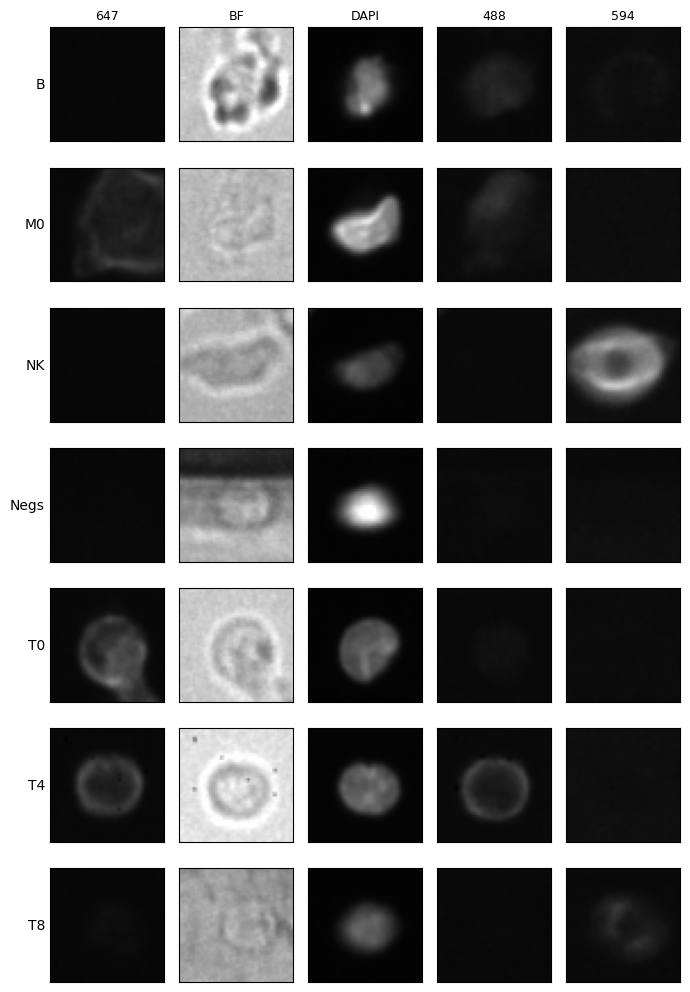

In [5]:
# one crop per cell type after step 1 (clip and scale): 0 = black, ceiling = white,
# the same range for every cell, so a channel without its marker stays dark
ceilings = np.asarray(prep["max_vals_clip"], dtype=np.float32)
fig, axes = plt.subplots(len(classes), 5, figsize=(7, 1.45 * len(classes)))
for row, c in zip(axes, classes):
    img = np.minimum(imgs[np.flatnonzero(labels == c)[0]], ceilings) / ceilings
    for ax, ch in zip(row, range(5)):
        ax.imshow(img[..., ch], cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]), ax.set_yticks([])
    row[0].set_ylabel(c, rotation=0, ha="right", va="center")
for ax, name in zip(axes[0], ["647", "BF", "DAPI", "488", "594"]):
    ax.set_title(name, fontsize=9)
fig.tight_layout()

## 4. Embed

In [6]:
@torch.no_grad()
def embed(imgs, prep, batch_size=512):
    out = []
    for i in range(0, len(imgs), batch_size):
        x = torch.stack([preprocess(img, prep) for img in imgs[i:i + batch_size]])
        out.append(model(x.to(DEVICE)).float().cpu().numpy())
    return np.concatenate(out)


emb = embed(imgs, prep)
print("embeddings:", emb.shape)

embeddings: (7000, 128)


## 5. Classify the cell types

A linear head (logistic regression on the standardized embeddings), with 5-fold
cross-validation: each crop is classified by a head fitted on the other four folds.
The backbone stays frozen and never saw a label; the labels are used only here.

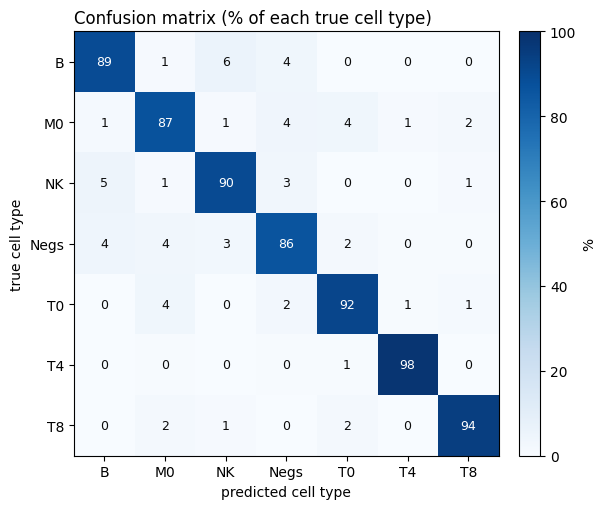

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

head = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
folds = StratifiedKFold(5, shuffle=True, random_state=0)
pred = cross_val_predict(head, emb, labels, cv=folds)

cm = confusion_matrix(labels, pred, labels=classes)
recall = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(recall, cmap="Blues", vmin=0, vmax=100)
for i in range(len(classes)):
    for j in range(len(classes)):
        v = recall[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9,
                color="white" if v > 60 else "#0b0b0b")
ax.set_xticks(range(len(classes)), classes)
ax.set_yticks(range(len(classes)), classes)
ax.set_xlabel("predicted cell type")
ax.set_ylabel("true cell type")
ax.set_title("Confusion matrix (% of each true cell type)", loc="left")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="%")
fig.tight_layout()

## 6. Your own data: which constants?

**These constants are ideally fixed.** The model was trained with them. For data
from the training setup (the public PBMC data, or the same microscope, staining and
acquisition settings), use them unchanged.

**Other imaging setups** can give very different raw intensities: another camera or
bit depth (8-bit instead of 16-bit), other exposure times, light sources or stains.
With the model's constants, such data can be clipped almost completely, or fill only
a small part of [0, 1]. The model can then perform poorly, **without any error
message**.

**We do not know yet how to best adapt the model to such data.** If it performs
poorly, adapting the constants with `calibrate` is a promising first thing to try:

1. **Start with the clip ceilings**, to get a good normalization of your data to
   [0, 1]. `calibrate` sets each ceiling to the 99th percentile of its channel. With
   cell-type labels, it takes the 99th percentile per cell type and then the highest
   one, as for the model's own values. This matters for marker channels, which are
   bright in only some cell types: over all crops together, the percentile is lower
   for them.
2. **Then also the mean and std** may be worth a try, recomputed after the new clip
   and scale.

Use a representative sample (a few thousand crops, all cell types present, same
channel order), and compare the variants on labelled data from your setup, for
example with a linear head as in section 5.

Recomputing normalization statistics on new data is a known, simple remedy for
domain shift with natural images. New constants cannot
correct differences in resolution, optics or staining patterns.

Below, `calibrate` on the public sample gives values in the same range as the
model's own, because it is the same setup. They are not identical: the percentiles
depend on the sample. For data from the training setup, keep the model's values.

In [8]:
mine = calibrate(imgs, labels)  # labels are optional
print(f"{'channel':34} {'ceiling: model':>14} {'calibrated':>10}   {'mean: model':>11} {'calibrated':>10}")
for i, name in enumerate(CHANNELS):
    print(f"{name:34} {prep['max_vals_clip'][i]:14.0f} {mine['max_vals_clip'][i]:10.0f}"
          f"   {prep['mean'][i]:11.4f} {mine['mean'][i]:10.4f}")

# for your own data:
#   my_prep = {**prep, **calibrate(my_imgs)}
#   emb = embed(my_imgs, my_prep)
# or with the script:  python embed.py --data MY_DIR --calibrate my_prep.json
#                      python embed.py --model ... --data MY_DIR --preprocessing my_prep.json --out my.npz

channel                            ceiling: model calibrated   mean: model calibrated
647 nm (CD3, CD14)                           3713       3306        0.0972     0.0986
Brightfield                                  1298       1306        0.7408     0.7861
DAPI                                         6904       5705        0.1030     0.1021
488 nm (CD4, CD19)                           3412       4539        0.0761     0.0570
594 nm (CD8, CD16, CD20, CD56)               3134       2579        0.0893     0.1120


**Cautionary note**

We have not tested this on any other dataset than the one we trained on. Changing the preprocessing constants can drastically change model behavior, so experimentation and potentially retraining might be needed. We're happy to hear about your experiences though!